Laboratorio di Web Scraping 
RATINGS: scRaping and AnalyzIng biTcoIN mininG poolS 
Progetto di Fine Corso A.A. 2023/24 

Lo scopo del progetto è l’implementazione di un insieme di tecniche di deanonimizzazione e di analisi 
dei miners della blockchain di Bitcoin. E’ necessario lavorare sia su un DataSet, fornito con il progetto,  
contenente un sottoinsieme delle transazioni di Bitcoin, che sul sito WalletExplorer, per la parte di 
scraping. Vengono richieste  un insieme di analisi generali sulle transazioni contenute nel DataSet di 
Bitcoin, quindi un insieme di analisi che sfruttano dati ottenuti mediante scraping.  

1) Descrizione del DataSet 

Viene fornito un DataSet di Bitcoin che contiene una selezione delle transazioni incluse nei blocchi 
compresi tra il blocco Genesis, minato da Satoshi Nakamoto in data 03-01-2009, 17:15:05 e 
il blocco di altezza 214562, minato in data 31-12-2012, 11:52:37. Il DataSet è stato ottenuto 
tramite una serie di trasformazioni effettuate sui dati pubblici reperiti dalla blockchain di Bitcoin, 
con lo scopo di diminuire la dimensione. In particolare: 
    
    ● alcuni campi della transazione (versione del protocollo, time lock, …etc) non sono stati considerati 
    
    ● gli hash delle transazioni, gli indirizzi contenuti negli output delle transazioni, e gli script sono 
    stati sostituiti con identificatori univoci interi. La corrispondenza tra gli indirizzi della 
    blockchain e gli identificatori univoci del DataSet  è stata memorizzata in un ulteriore file di 
    mapping. La corrispondenza tra script e rispettivi identificatori è fornita in Tab. 1. 

Il DataSet consiste di   4 files CSV:
    
    ● transactions.csv, che contiene una riga per ogni transazione del DataSet, con i campi: 
    timestamp: timestamp del blocco che contiene la transazione.  Corrisponde al tempo 
    UNIX del miner che ha inserito la transazione nel blocco minato, e indica il momento in 
    cui il blocco è stato minato 
    blockId: identificatore del blocco che contiene  la transazione. Indica l’altezza di tale 
    blocco, ovvero la sua distanza dal blocco genesis di Bitcoin 
    txId:  identificatore unico della transazione corrispondente all’hash del contenuto della 
    transazione 
    isCoinbase: indica se la transazione è una Coinbase, ovvero una transazione che 
    trasferisce la ricompensa al miner che ha risolto la PoW (0 false, 1 true) 
    fee: eventuale commissione volontaria contenuta nella transazione, attribuita al miner 
    che la inserisce in un blocco. Può essere zero. 
    inputs.csv, che contiene una riga per ogni campo di input di ogni transazione del DataSet, con 
    i campi: 
    txId: identificatore della transazione all’interno della quale si trova questo input 
    prevTxId: identificatore della transazione che ha creato l’output attualmente speso da 
    questo input 
    prevTxpos: posizione dell’output attualmente speso come input, all’interno della 
    transazione che lo ha creato (diversa da quella che contiene questo input) 
    
    ● outputs.csv, che contiene una riga per ogni campo di output di ogni transazione del 
    DataSet, con i campi: 
    txId: identificatore della transazione all’interno della quale si trova questo output 
    position: posizione di questo output all’interno della transazione che lo ha creato 
    addressId: indirizzo a cui viene inviato questo output, è un identificatore univoco che 
    viene mappato nell’indirizzo reale (hash) tramite il file mapping.csv 
    amount: valore trasferito da questo output 
    scripttype:  codice che identifica lo script contenuto in questo output. Gli script 
    possono essere di diversi tipi (la Tabella 1 mostra i tipi di script definiti da  Bitcoin e il 
    rispettivo codice contenuto nel DataSet). Tuttavia, dato che il DataSet contiene solo 
    transazioni generate nei primi 4 anni di vita di Bitcoin, solo i primi 4 script della tabella 
    sono significativi per questo DataSet. Se lo script è di tipo 0 significa che lo script non è 
    standard e spesso non ha un address associato. 
    
    ● mapping.csv, file di mapping degli indirizzi, campi: 
    addressId: identificatore unico di ogni indirizzo contenuto in almeno un output delle 
    transazioni del DataSet.  
    hash: hash corripondente all’indirizzo. E’ l’hash del corrispondente indirizzo contenuto 
    nella blockchain di Bitcoin. 
    Nel caso di output con script di tipo 0 che non contengono address, nel file di mapping si 
    trova un identificatore univoco rappresentato da una # seguita da un numero che 
    rappresenta quell’output e solo quello, associato con l’identificatore utilizzato per 
    quell’output nel DataSet. . 

La struttura del DataSet è mostrata in Fig.1. (vedere pdf)

In [4]:
import pandas as pd

#pd.set_option("mode.copy_on_write", True) //di default è true

df_Inputs = pd.read_csv("Dataset/inputs.csv", names=["txId","prevTxId","prevTxpos"])
df_Outputs = pd.read_csv("Dataset/outputs.csv", names=["txId", "position", "addressId", "amount", "scripttype"])
df_Mapping = pd.read_csv("Dataset/mapping.csv", names=["addressId","hash"])
df_Transactions = pd.read_csv("Dataset/transactions.csv", names=["timestamp", "blockId", "txId", "isCoinsBase", "fee"])
df_Transactions['timestamp'] = pd.to_datetime(df_Transactions['timestamp'], unit='s')

print(f"INPUTS:\n{df_Inputs}\n\n")
print(f"OUTPUTS:\n{df_Outputs}\n\n")
print(f"MAPPING:\n{df_Mapping}\n\n")
print(f"TRANSACTIONS:\n{df_Transactions}")

INPUTS:
              txId  prevTxId  prevTxpos
0              171         9          0
1              183       171          1
2              185       183          1
3              187       185          1
4              192       187          0
...            ...       ...        ...
21378765  10572823  10572820          7
21378766  10572824  10572820          5
21378767  10572825  10572820          6
21378768  10572826  10572820          2
21378769  10572826  10569364          4

[21378770 rows x 3 columns]


OUTPUTS:
              txId  position  addressId      amount  scripttype
0                0         0          0  5000000000           1
1                1         0          1  5000000000           1
2                2         0          2  5000000000           1
3                3         0          3  5000000000           1
4                4         0          4  5000000000           1
...            ...       ...        ...         ...         ...
24613794  10572825      

2) ANALISI generali dei dati della blockchain.

E’ richiesto di implementare le seguenti analisi sul segmento iniziale di transazioni di Bitcoin contenuto 
nel DataSet:

------------------------------------------------------------------------------------------
    1 - studiare l’andamento delle fee contenute nelle transazioni rispetto alla congestione della blockchain, trascurando le transazioni CoinBase, che forniscono le ricompense ai miner e quindi non contengono fee. Lo scopo è verificare se all’aumentare della congestione della chain aumentino anche le fee (come accade anche con il meccanismo del gas sulla blockchain di Ethereum). La congestione della rete in un certo intervallo di tempo viene misurata come somma della dimensione delle transazioni presenti quell’intervallo. La dimensione in byte di una transazione può essere calcolata mediante la seguente formula: size(transaction)=  size(input)* n_inputs+ size (output)* n_outputs + size (script) ovvero è ottenuta sommando la dimensione media in byte di ogni input moltiplicata per il numero di input della transazione, la dimensione media in byte di ogni output moltiplicata per il numero di output e la dimensione dello script della transazione. La dimensione media di ogni script è mostrata in Tabella 1, mentre le dimensioni medie di ogni input e di ogni output valgono, rispettivamente, 40 bytes e 9 bytes. 
--------------------------------------------------------

In [5]:
#Voglio togliere le coinbase perché non mi servono in questo tipo di analisi.

df_Transactions_no_coinbase = df_Transactions[(df_Transactions["isCoinsBase"] == 0)] #& df_Transactions["fee"]>0]
df_Transactions_no_coinbase

,timestamp,blockId,txId,isCoinsBase,fee
171,2009-01-12 03:30:25,170,171,0,0
183,2009-01-12 06:02:13,181,183,0,0
185,2009-01-12 06:12:16,182,185,0,0
187,2009-01-12 06:34:22,183,187,0,0
192,2009-01-12 07:16:40,187,192,0,0
...,...,...,...,...,...
10572824,2012-12-31 23:52:37,214562,10572822,0,100000
10572825,2012-12-31 23:52:37,214562,10572823,0,100000
10572826,2012-12-31 23:52:37,214562,10572824,0,100000
10572827,2012-12-31 23:52:37,214562,10572825,0,100000


In [6]:
# 1 - primo punto

size_Input = 40 # intero che rappresenta: bytes
size_Output = 9 # intero che rappresenta: bytes

# funzione che preso il tipo dello script come valore intero mi restituisce un intero che sarebbe la corrispettiva dimensione
def sizeScript(scripttype):
    if scripttype==1:
        return 153
    if scripttype==2:
        return 180
    if scripttype==3:
        return 291
    return 0
    
#creo 2 dataframe: uno per una join tra transactions - inputs e l'altro per transactions - outputs. 
df_Inputs_Transactions = df_Transactions_no_coinbase.merge(df_Inputs, on="txId")
df_Transactions_Outputs = df_Transactions_no_coinbase.merge(df_Outputs, on="txId")

print(f"INPUTS_TRANSACTIONS:\n{df_Inputs_Transactions}\n\n")
print(f"TRANSACTIONS_OUTPUTS:\n{df_Transactions_Outputs}\n")

INPUTS_TRANSACTIONS:
                   timestamp  blockId      txId  isCoinsBase     fee  \
0        2009-01-12 03:30:25      170       171            0       0   
1        2009-01-12 06:02:13      181       183            0       0   
2        2009-01-12 06:12:16      182       185            0       0   
3        2009-01-12 06:34:22      183       187            0       0   
4        2009-01-12 07:16:40      187       192            0       0   
...                      ...      ...       ...          ...     ...   
21378765 2012-12-31 23:52:37   214562  10572823            0  100000   
21378766 2012-12-31 23:52:37   214562  10572824            0  100000   
21378767 2012-12-31 23:52:37   214562  10572825            0  100000   
21378768 2012-12-31 23:52:37   214562  10572826            0  100000   
21378769 2012-12-31 23:52:37   214562  10572826            0  100000   

          prevTxId  prevTxpos  
0                9          0  
1              171          1  
2              183

In [7]:
# raggruppo il dataframe degli input per transazioni e calcolo la dimensione totale degli input per raggruppamento.
df_Inputs_Transactions = df_Inputs_Transactions.groupby(["txId","timestamp","fee"]).agg(
    total_input_size=('txId', lambda x: len(x) * size_Input)
).reset_index()

# funzione per il calcolo della dimensione totale degli script degli output di una transazione. 
def GetSumSizeScriptOfTransaction(x):
    sum_Size_Scripts=0
    for el in x:
        sum_Size_Scripts+=sizeScript(el)
    return sum_Size_Scripts
    

# raggruppo il dataframe degli output per transazioni e calcolo la dimensione totale degli output 
# (incluso la dimensione dello script) per raggruppamento.
df_Transactions_Outputs = df_Transactions_Outputs.groupby(["txId","timestamp","fee"]).agg(
   total_output_size=('scripttype', lambda x: len(x) * size_Output + GetSumSizeScriptOfTransaction(x) ) #sizeScript(x.iloc(0))
).reset_index()


df_Trans_Inputs_Outputs = pd.merge(df_Inputs_Transactions, df_Transactions_Outputs, on=["txId","timestamp","fee"], how='outer').fillna(0)

del df_Inputs_Transactions
del df_Transactions_Outputs

df_Trans_Inputs_Outputs["size_transaction"]= df_Trans_Inputs_Outputs["total_input_size"] + df_Trans_Inputs_Outputs["total_output_size"]

# creo una nuova colonna intervallo di tempo ottenuta arrotondando i timestamp in giorni
df_Trans_Inputs_Outputs['time_interval'] = df_Trans_Inputs_Outputs['timestamp'].dt.floor('d')

df_Trans_Inputs_Outputs

,txId,timestamp,fee,total_input_size,total_output_size,size_transaction,time_interval
0,171,2009-01-12 03:30:25,0,40,324,364,2009-01-12
1,183,2009-01-12 06:02:13,0,40,324,364,2009-01-12
2,185,2009-01-12 06:12:16,0,40,324,364,2009-01-12
3,187,2009-01-12 06:34:22,0,40,324,364,2009-01-12
4,192,2009-01-12 07:16:40,0,40,162,202,2009-01-12
...,...,...,...,...,...,...,...
10358261,10572822,2012-12-31 23:52:37,100000,40,378,418,2012-12-31
10358262,10572823,2012-12-31 23:52:37,100000,40,378,418,2012-12-31
10358263,10572824,2012-12-31 23:52:37,100000,40,378,418,2012-12-31
10358264,10572825,2012-12-31 23:52:37,100000,40,378,418,2012-12-31


In [8]:
# raggruppo per intervallo di tempo e faccio la somma della dimensione delle transazioni ottenendo il dataframe delle congestioni.
congestion = df_Trans_Inputs_Outputs.groupby('time_interval')['size_transaction'].sum().reset_index(name='congestion')

# Raggruppo per intervallo di tempo e faccio la media delle fee.
fees = df_Trans_Inputs_Outputs.groupby('time_interval')['fee'].mean().reset_index(name='average_fee')

del df_Trans_Inputs_Outputs

# Unisco i due dataframe: congestion e fees
df_analysis = pd.merge(congestion, fees, on='time_interval')

print(f"DATAFRAME PRONTO PER ESSERE ANALIZZATO:\n{df_analysis}")

df_analysis = df_analysis.set_index("congestion")
df_analysis['average_fee'].describe()

DATAFRAME PRONTO PER ESSERE ANALIZZATO:
     time_interval  congestion   average_fee
0       2009-01-12        2224      0.000000
1       2009-01-14         282      0.000000
2       2009-01-15        2868      0.000000
3       2009-01-16         511      0.000000
4       2009-01-18         282      0.000000
...            ...         ...           ...
1194    2012-12-27    23102929  84655.810800
1195    2012-12-28    25069147  79669.692794
1196    2012-12-29    20897913  78701.765474
1197    2012-12-30    23399703  77386.642764
1198    2012-12-31    16611016  81661.142313

[1199 rows x 3 columns]


count    1.199000e+03
mean     2.235287e+05
std      1.430671e+06
min      0.000000e+00
25%      0.000000e+00
50%      6.001043e+04
75%      8.494528e+04
max      2.236667e+07
Name: average_fee, dtype: float64

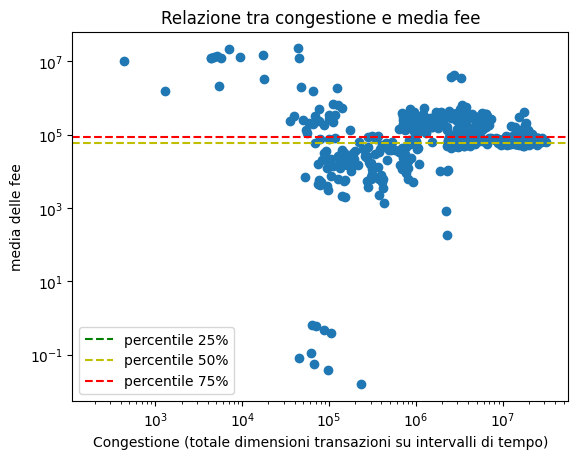

In [7]:
import matplotlib.pyplot as plt

plt.scatter(df_analysis.index,df_analysis["average_fee"])
plt.xlabel('Congestione (totale dimensioni transazioni su intervalli di tempo)')
plt.ylabel('media delle fee')
plt.yscale('log')
plt.xscale('log')

#metto delle linee orizzontali per inidividuare i percentili
plt.axhline(y=0, color='g', linestyle='--', label='percentile 25%')
plt.axhline(y=60010.43, color='y', linestyle='--', label='percentile 50%')
plt.axhline(y=84945.28, color='r', linestyle='--', label='percentile 75%')

plt.title('Relazione tra congestione e media fee')
plt.legend()
plt.show()

RELAZIONE DEL PUNTO 1 DELL'ANALISI:

Dal grafico possiamo vedere come la media delle fee si addensa da certi valori di congestione in poi.

Il primo quartile (percentile 25%) è 0, significa che una buona parte delle transazioni non ha fee.

Poi notiamo anche qualche valore estremo sparso, ma possiamo considerarli come outliers o valori anomali:
Il valore massimo delle fee è 22,366,670. Questo valore è molto elevato, suggerendo la presenza di alcune transazioni con fee straordinariamente alte (potrebbe trattarsi di outliers o transazioni particolari).

Questo potrebbe suggerire che i miner che vogliono prioritizzare la convalida delle proprie transazioni siano disposti a pagare delle fee quando si raggiunge un certo livello di congestione.

--------------------------------------

-----------------------------------------------------------------------------------------
    2 - analizzare i tipi di script contenuti nel dataset, evidenziando se e come sia cambiato nel corso dei primi 3 anni della vita di Bitcoin il loro utilizzo.

In [ ]:
#Voglio vedere quale tipo di script viene usato ogni anno.
#df_Tr_Out["timestamp"]=df_Tr_Out["timestamp"].dt.year
#years=df_Tr_Out["timestamp"].dt.year.unique()
#for year in years:
#    print( f"Anno {year}: ") 
#    print((df_Tr_Out[ df_Tr_Out["timestamp"] == year ])["scripttype"].unique())

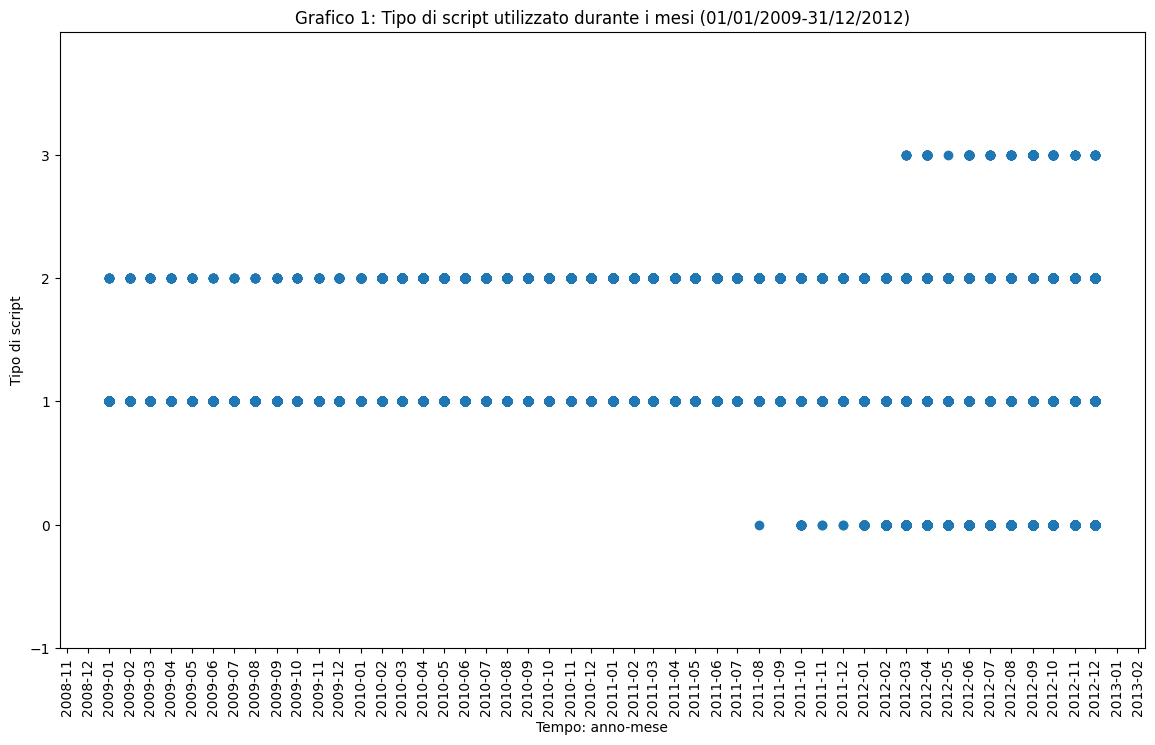

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np


#Voglio vedere quale tipo di script viene usato ogni mese dell'anno per l'intero periodo.

#riprendo il dataframe che unisce transazioni e outputs, 
df_Transactions_Outputs = df_Transactions.merge(df_Outputs, on="txId")

#poi setto le date a inizio mese.
df_Transactions_Outputs['timestamp'] = df_Transactions_Outputs['timestamp'].dt.to_period('M').dt.start_time

#Grafico 1
plt.figure(figsize=(14, 8))
#un'altra alternativa: heatmap di seaborn
plt.scatter(df_Transactions_Outputs["timestamp"], df_Transactions_Outputs['scripttype'])
plt.ylim(-1,4)
plt.yticks(np.arange(-1,4,1))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
plt.xticks(rotation=90)
plt.title('Grafico 1: Tipo di script utilizzato durante i mesi (01/01/2009-31/12/2012)')
plt.xlabel('Tempo: anno-mese')
plt.ylabel('Tipo di script')
plt.show()

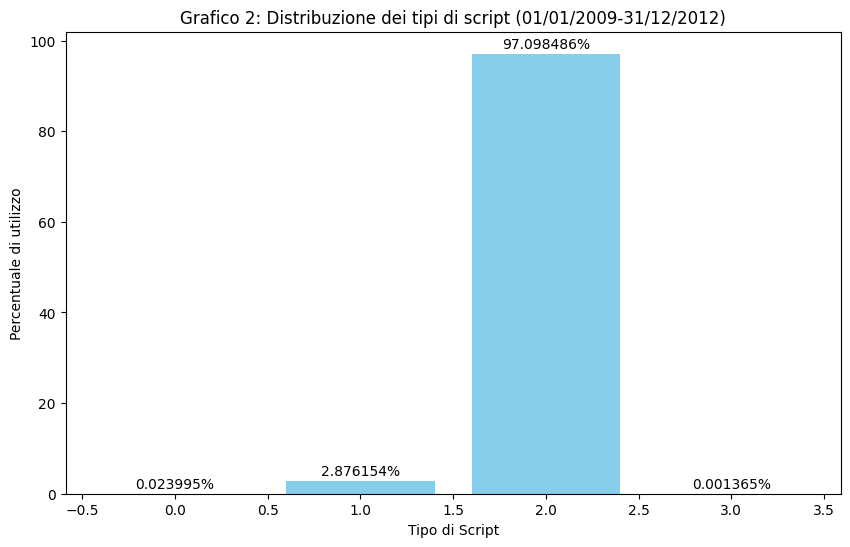

In [9]:

#preparazione dati per il grafico: 
#creo una series con indice il tipo di script e come valore le sue occorrenze nell'outputs delle transazioni
df_scriptTypes_count = df_Transactions_Outputs['scripttype'].value_counts()
#normalizzo i conteggi ottenuti precedentemente: divido ciascun conteggio per la somma totale e moltiplico per 100 per ottenere la percentuale.
df_scriptTypes_count =  df_scriptTypes_count / df_scriptTypes_count.sum() * 100

#Grafico 2
plt.figure(figsize=(10, 6))  # Imposta la dimensione della figura
bars = plt.bar(df_scriptTypes_count.index, df_scriptTypes_count.values, color='skyblue')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.5, f'{yval:.6f}%', ha='center', va='bottom', fontsize=10)
plt.title('Grafico 2: Distribuzione dei tipi di script (01/01/2009-31/12/2012)')
plt.xlabel('Tipo di Script')
plt.ylabel('Percentuale di utilizzo')
plt.show()

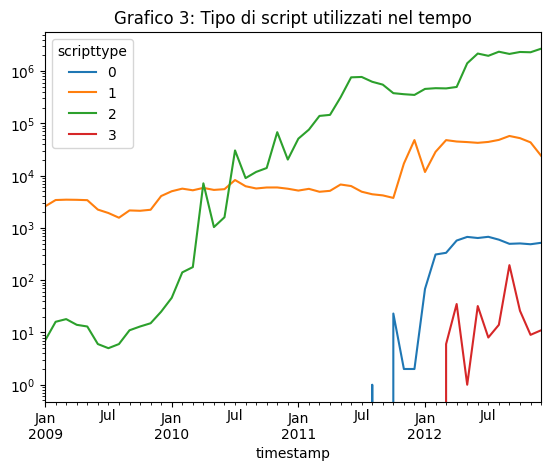

In [10]:
#Raggruppo per tempo e tipo di script,
#.size raggruppa la dimensione del gruppo, quindi righe per ogni combinazione tempo/tipo_script.
#.unstack: creo un dataframe con [ tempo , i vari tipi di script in colonne].
#il risultato è che per ogni mese nella rispettiva colonna del tipo di script, viene inserito quante volte è usato lo script.
#se una combinazione di timestamp e scripttype non è presente, fill_value imposta il valore a 0.
script_counts = df_Transactions_Outputs.groupby(['timestamp', 'scripttype']).size().unstack(fill_value=0)

#creo il Grafico 3
script_counts.plot()
plt.yscale('log')
plt.title('Grafico 3: Tipo di script utilizzati nel tempo')
plt.show()

RELAZIONE DEL PUNTO 2 DELL'ANALISI:

Dai risultati ottenuti dal primo grafico, possiamo osservare che nei primi anni di vita di Bitcoin, ossia nel 2009 e nel 2010, sono stati utilizzati esclusivamente gli script di tipo 1 e 2. A partire dal 2011, vediamo l'introduzione di nuovi tipi di script: prima il tipo 0 nel 2011, seguito dal tipo 3 nel 2012.

Il secondo grafico evidenzia che, tra i tipi di script utilizzati, il tipo 2 è quello che domina, con un utilizzo prevalente. Il tipo 1, invece, è presente, ma in misura decisamente inferiore rispetto al tipo 2.

Infine, il terzo grafico ci mostra come l'utilizzo di questi script sia cambiato nel tempo. Notiamo che, inizialmente nel 2009, il tipo 1 era il più utilizzato, ma a partire dalla metà del 2010, il tipo 2 ha preso il sopravvento, con un incremento esponenziale nell'utilizzo.

------------------------------------------------

---------------------------------------------------


3. Analisi delle Mining Pool

In questa parte di RATINGS  si dovrà implementare un web scraper il cui scopo è provare a 
deanonimizzare  gli indirizzi contenuti nelle Coinbase contenute nel DataSet, con lo  scopo di analizzare 
il comportamento delle mining pool attive nel periodo considerato. 
A questo scopo si consiglia di leggere inizialmente il paper[1] (allegato al progetto). Il paper evidenzia 
come, nel periodo considerato nel DataSet, fossero attivi solo i seguenti mining pools: DeepBit, 
Eligius, BTC Guild, BitMinter. Ovviamente, durante tale periodo, erano attivi anche 
utenti singoli che partecipavano al processo di mining, ad esempio lo stesso Satoshi Nakamoto. Anche 
tali utenti possono aver generato delle Coinbase. 
Il processo di deanonimizzazione dovrà utilizzare WalletExplorer: si tratta di un servizio che 
collega un insieme di indirizzi Bitcoin a servizi noti (ad esempio piattaforme di exchange, servizi 
di gambling, marketplaces, etc). In Fig. 2 è mostrata la pagina iniziale di Wallet Explorer 
(https://www.walletexplorer.com/) in cui si può notare come sia possibile immettere un indirizzo 
presente sulla blockchain di Bitcoin per ottenere, se presente, la specifica del servizio/wallet 
corrispondente. Tuttavia inserire l’indirizzo di ogni Coinbase richiederebbe un massiccio impiego del 
processo di scraping, perché potenzialmente potrebbe essere necessario deanonimizzare almeno 
214562 indirizzi, uno o più per ogni blocco e quindi per ogni Coinbase presente nel DataSet. Il 
numero di richieste al server  risulterebbe quindi decisamente molto elevato, anche se possibilmente 
riducibile ad esempio mediante caching degli indirizzi. 
Come soluzione alternativa, come mostrato in Fig.3, ricercando ad esempio la mining pool Eligius e 
cliccando successivamente sul nome della MiningPool, è possibile ottenere l’insieme di tutti gli indirizzi 
contenuti nel wallet della MiningPool, così come le transazioni effettuate da/verso quegli indirizzi. E’ 
quindi possibile, tramite scraping reperire tutti gli indirizzi associati alle quattro mining pool attive 
durante il periodo considerato (non è consentito scaricare il file .csv contenente gli indirizzi) 

Si richiede quindi di: 

● reperire, mediante scraping, tutti gli indirizzi associati alle 4 mining pool considerate ed 
utilizzare gli indirizzi scaricati per deanonimizzare gli indirizzi utilizzati nelle Coinbase presenti 
nel DataSet. Per quanto riguarda le Coinbase che presentano indirizzi non appartenenti a 
nessuna delle 4 mining pool, provare a deanonimizzare tramite WalletExplorer i 4 miners che 
hanno prodotto più transazioni Coinbase (riferiti come top 4 miners), e raggruppare tutti gli 
altri in una categoria “Others” 

In [11]:
#dataframe contenente solo transazioni coinbase
df_Coinbase = df_Transactions [ df_Transactions["isCoinsBase"] == 1 ]
print(f"TRANSAZIONI COINBASE:\n{df_Coinbase}")

#left join tra df_coinbase e df_outputs per avere gli outputs dei soli coinbase
df_Temp = df_Coinbase.merge(df_Outputs[["txId","addressId"]], on="txId", how="left")
#Right join per avere la mappatura degli indirizzi dei soli outputs precendetemente ricavati
df_da_deanomizzare = df_Mapping[["addressId","hash"]].merge(df_Temp, left_on="hash", right_on="addressId", how='right')
#prendo solo le colonne addressId e txId
df_da_deanomizzare = df_da_deanomizzare[["addressId_x","txId"]]
#ma devo rinominare addressId perché se ne sono creati due a causa dell'ultima join
df_da_deanomizzare.rename(columns={ "addressId_x" : "addressId" }, inplace=True)

del df_Temp

df_da_deanomizzare

TRANSAZIONI COINBASE:
                   timestamp  blockId      txId  isCoinsBase  fee
0        2009-01-03 18:15:05        0         0            1    0
1        2009-01-09 02:54:25        1         1            1    0
2        2009-01-09 02:55:44        2         2            1    0
3        2009-01-09 03:02:53        3         3            1    0
4        2009-01-09 03:16:28        4         4            1    0
...                      ...      ...       ...          ...  ...
10571749 2012-12-31 23:21:12   214558  10571747            1    0
10572167 2012-12-31 23:32:34   214559  10572165            1    0
10572426 2012-12-31 23:51:48   214560  10572424            1    0
10572427 2012-12-31 23:46:31   214561  10572425            1    0
10572569 2012-12-31 23:52:37   214562  10572567            1    0

[214563 rows x 5 columns]


,addressId,txId
0,1A1zP1eP5QGefi2DMPTfTL5SLmv7DivfNa,0
1,12c6DSiU4Rq3P4ZxziKxzrL5LmMBrzjrJX,1
2,1HLoD9E4SDFFPDiYfNYnkBLQ85Y51J3Zb1,2
3,1FvzCLoTPGANNjWoUo6jUGuAG3wg1w4YjR,3
4,15ubicBBWFnvoZLT7GiU2qxjRaKJPdkDMG,4
...,...,...
508799,1FeKwcQ4o5Eh7nsRDdG6jx8ysGzgBSij4S,10571747
508800,14cZMQk89mRYQkDEj8Rn25AnGoBi5H6uer,10572165
508801,19PkHafEN18mquJ9ChwZt5YEFoCdPP5vYB,10572424
508802,1GTHhYUAtMjNKUPWxvxfGHptZchKvWGaUs,10572425


In [12]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import argparse
import time
import random
import os
import pandas as pd
import numpy as np

# {url del wallet della mining pool : nome mining pool }
urls = dict([('https://www.walletexplorer.com/wallet/DeepBit.net/addresses' , 'DeepBit'), 
        ("https://www.walletexplorer.com/wallet/Eligius.st/addresses" , 'Eligius' ),
        ('https://www.walletexplorer.com/wallet/BTCGuild.com/addresses', 'BTCGuild'),
        ('https://www.walletexplorer.com/wallet/BitMinter.com/addresses', 'BitMinter')])

#creo il dizionario options dal metodo costruttore ChromeOptions di webdriver
options = webdriver.ChromeOptions()

#creo il dizionario prefs per gestire i cookies
prefs = {
        "profile.default_content_setting_values.cookies": 1,  # 2: Blocca, 1: Consenti, 0: Rilevamento
        "profile.managed_default_content_settings.cookies": 2
    }

# aggiungo le preferenze all'oggetto options
options.add_experimental_option("prefs", prefs)

service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=options)

#aggiungo colonna name_entity inizialmente tutta nan, da riempire durante lo scraping.
df_da_deanomizzare["name_entity"] = np.nan
df_da_deanomizzare["name_entity"] = df_da_deanomizzare["name_entity"].astype(str)
df_da_deanomizzare.set_index('addressId', inplace=True)

#funzione che mi permette di scorrere le pagine del wallet della mining pool
#restituisce vero se è entrato nella pagina successiva
#altrimenti falso e quindi non ci sono pagine da scorrere.
def next_page():
    try:
        div_paging = driver.find_element(By.CLASS_NAME, "paging")
        elements_a = div_paging.find_elements(By.TAG_NAME, "a")
        for a in elements_a:
            if a.text.strip() == "Next…" :
                a.click()
                WebDriverWait(driver, 10).until(
                    lambda driver: driver.execute_script("return document.readyState") == "complete"
                )
                return True
        return False
    except:
        return False

#per ogni mining pool prendiamo url e nome
#qui faccio webscraping per prendere gli indirizzi nel wallet di ogni mining pool
#controllare se siano tra gli indirizzi che già avevo nel mio dataframe df_da_deanomizzare
#se sì, allora deanomizzo tutti gli indirizzi associati con il nome della mining pool
#altrimenti vado avanti.
for url, entity in urls.items():
    driver.get(url)
    
    WebDriverWait(driver, 10).until(
                lambda driver: driver.execute_script("return document.readyState") == "complete"
    )

    while True:
        time.sleep(random.uniform(2, 5))
        tbody = driver.find_element(By.TAG_NAME, 'tbody')
        list_tr = tbody.find_elements(By.TAG_NAME, 'tr')

        for tr in list_tr[1:]:
            td = tr.find_element(By.TAG_NAME, 'td')
            address = td.text
            if address in df_da_deanomizzare.index:
                df_da_deanomizzare.loc[df_da_deanomizzare.index == address, "name_entity"] = entity
                #print(df_da_deanomizzare.loc[address]["txId"])
        if not next_page():
            break
            
#PER DEBUG
#df_da_deanomizzare.to_csv('df_da_deanomizzare.csv', index=True)

time.sleep(3)
driver.quit()

print(f"DATAFRAME RESTITUITO DALLO SCRAPING:\n{df_da_deanomizzare}\n")
print(df_da_deanomizzare[ df_da_deanomizzare["name_entity"] == "DeepBit" ])
print(df_da_deanomizzare[ df_da_deanomizzare["name_entity"] == "Eligius" ])
print(df_da_deanomizzare[ df_da_deanomizzare["name_entity"] == "BTCGuild" ])
print(df_da_deanomizzare[ df_da_deanomizzare["name_entity"] == "BitMinter" ])

DATAFRAME RESTITUITO DALLO SCRAPING:
                                        txId name_entity
addressId                                               
1A1zP1eP5QGefi2DMPTfTL5SLmv7DivfNa         0         nan
12c6DSiU4Rq3P4ZxziKxzrL5LmMBrzjrJX         1         nan
1HLoD9E4SDFFPDiYfNYnkBLQ85Y51J3Zb1         2         nan
1FvzCLoTPGANNjWoUo6jUGuAG3wg1w4YjR         3         nan
15ubicBBWFnvoZLT7GiU2qxjRaKJPdkDMG         4         nan
...                                      ...         ...
1FeKwcQ4o5Eh7nsRDdG6jx8ysGzgBSij4S  10571747         nan
14cZMQk89mRYQkDEj8Rn25AnGoBi5H6uer  10572165    BTCGuild
19PkHafEN18mquJ9ChwZt5YEFoCdPP5vYB  10572424   BitMinter
1GTHhYUAtMjNKUPWxvxfGHptZchKvWGaUs  10572425         nan
14cZMQk89mRYQkDEj8Rn25AnGoBi5H6uer  10572567    BTCGuild

[508804 rows x 2 columns]

Empty DataFrame
Columns: [txId, name_entity]
Index: []
                                        txId name_entity
addressId                                               
1JVG3fKSHVnGh2q5TrjUG8MNR

In [13]:
#import pandas as pd
#PER DEBUG
#df_da_deanomizzare = pd.read_csv("df_da_deanomizzare.csv", names=["addressId","txId","name_entity"], header=0)
#df_da_deanomizzare.set_index("addressId",inplace=True)

#prendo uno schema del dataframe filtrato con il nome della mining pool: "nan", ovvero quelli che non ho deanomizzato.
df_mancanti = df_da_deanomizzare[ df_da_deanomizzare["name_entity"] == 'nan' ]

print(f"DF_MANCANTI (DA FINIRE DI DEANOMIZZARE):\n{df_mancanti}\n")

#creo il dataframe con indirizzi dei miners e quanti blocchi hanno minato in ordine decrescente
address_counts = df_mancanti.groupby('addressId')['txId'].nunique().reset_index()
address_counts = address_counts.sort_values(by='txId', ascending=False)

print(f"DATAFRAME DEGLI INDIRIZZI DEI MINER E QUANTI BLOCCHI HANNO MINATO IN ORDINE DECRESCENTE:\n{address_counts}")

#filtro solo i primi 4, ovvero i top 4 miners
top_4_miners = address_counts.head(4)
print(f" top 4 miners: {top_4_miners}")

#estraggo la series dal dataframe dei top_4_miners
top_4_addresses = top_4_miners["addressId"]
#nel dataframe che sto deanomizzando, inserisco la deanomizzazione "top 4 miners" negli indirizzi corrispondenti.
df_da_deanomizzare.loc[df_da_deanomizzare.index.isin(top_4_addresses), "name_entity"] = "top_4_miners"

print("\nDF DEANOMIZZATO CON I 4 TOP MINERS:\n")
print(df_da_deanomizzare [ df_da_deanomizzare["name_entity"]=="top_4_miners"])

#adesso che ho finito di deanomizzare, sostituisco gli indirizzi ancora sconosciuti, i nan, con OTHERS
df_da_deanomizzare.loc[df_da_deanomizzare["name_entity"] == 'nan', "name_entity"] = "Others"

print("\nDF DEANOMIZZATO:\n")
print(df_da_deanomizzare [ df_da_deanomizzare["name_entity"]=="Others"])

df_da_deanomizzare.shape

DF_MANCANTI (DA FINIRE DI DEANOMIZZARE):
                                        txId name_entity
addressId                                               
1A1zP1eP5QGefi2DMPTfTL5SLmv7DivfNa         0         nan
12c6DSiU4Rq3P4ZxziKxzrL5LmMBrzjrJX         1         nan
1HLoD9E4SDFFPDiYfNYnkBLQ85Y51J3Zb1         2         nan
1FvzCLoTPGANNjWoUo6jUGuAG3wg1w4YjR         3         nan
15ubicBBWFnvoZLT7GiU2qxjRaKJPdkDMG         4         nan
...                                      ...         ...
17w9uVZuPgsY7iLBVGB7qTZ1ZiZnTJKHLq  10571665         nan
#5893                               10571695         nan
1JkTWpeJUwu9Mbhpk2EyF8Kh2J77bFab1p  10571704         nan
1FeKwcQ4o5Eh7nsRDdG6jx8ysGzgBSij4S  10571747         nan
1GTHhYUAtMjNKUPWxvxfGHptZchKvWGaUs  10572425         nan

[504181 rows x 2 columns]

DATAFRAME DEGLI INDIRIZZI DEI MINER E QUANTI BLOCCHI HANNO MINATO IN ORDINE DECRESCENTE:
                                 addressId  txId
56986   1811f7UUQAkAejj11dU5cVtKUSTfoSVzdm  2587
878

(508804, 2)

● analizzare le Coinbase deanonimizzate e produrre le seguenti statistiche: 

    1 - numero di blocchi minati da ciascuna delle 4 mining pool, sia globalmente, che 
    mostrando l’andamento temporale dei blocchi minati, per intervalli temporali di due 
    mesi (ed eventualmente quelli dei top 4 miners) ; 
    
    2 - distribuzione delle reward totali ricevute da ogni mining pool, sia globalmente che 
    mostrandone l'andamento temporale, sempre per intervalli di due mesi; 

In [14]:
#PREPARAZIONE DATI PER PUNTO 1

#dataframe in cui raggruppo per nome entità (name mining pool,4 top miner o others),
#creo una colonna nuova che rappresenta il numero delle transazioni uniche per ciascun gruppo 
block_counts = df_da_deanomizzare.groupby("name_entity")["txId"].nunique().reset_index(name='block_count')
block_counts

,name_entity,block_count
0,BTCGuild,1162
1,BitMinter,2023
2,Eligius,1227
3,Others,203321
4,top_4_miners,7985


Text(0, 0.5, 'Numero di blocchi minati')

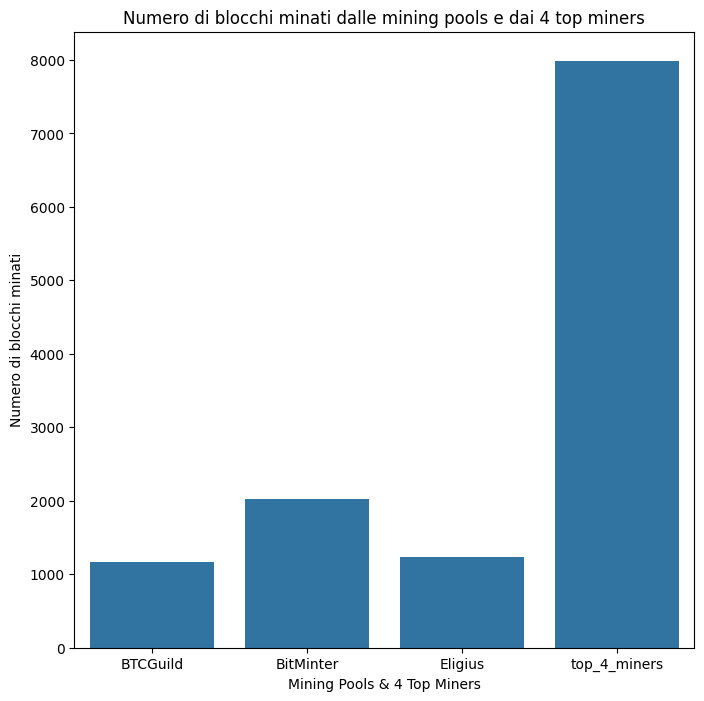

In [15]:
#NUMERO DI BLOCCHI MINATI GLOBALMENTE 

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import seaborn as sb

#filtro escludendo "Others" tra le deanomizzazioni
block_counts = block_counts[block_counts["name_entity"] != "Others"]

plt.figure(figsize=(8, 8))
sb.barplot(block_counts, x="name_entity",y="block_count")

plt.title('Numero di blocchi minati dalle mining pools e dai 4 top miners')
plt.xlabel('Mining Pools & 4 Top Miners')
plt.ylabel('Numero di blocchi minati')


DataFrame preparato per il grafico:
     name_entity two_months_interval  block_count
0       BTCGuild          2012-10-01          554
1       BTCGuild          2012-12-01          608
2      BitMinter          2011-10-01           25
3      BitMinter          2011-12-01           78
4      BitMinter          2012-02-01           78
5      BitMinter          2012-04-01          116
6      BitMinter          2012-06-01          217
7      BitMinter          2012-08-01          512
8      BitMinter          2012-10-01          738
9      BitMinter          2012-12-01          259
10       Eligius          2011-04-01           63
11       Eligius          2011-06-01           35
12       Eligius          2011-08-01           25
13       Eligius          2011-10-01           20
14       Eligius          2011-12-01           82
15       Eligius          2012-02-01          271
16       Eligius          2012-04-01          370
17       Eligius          2012-06-01          265
18       Eligi

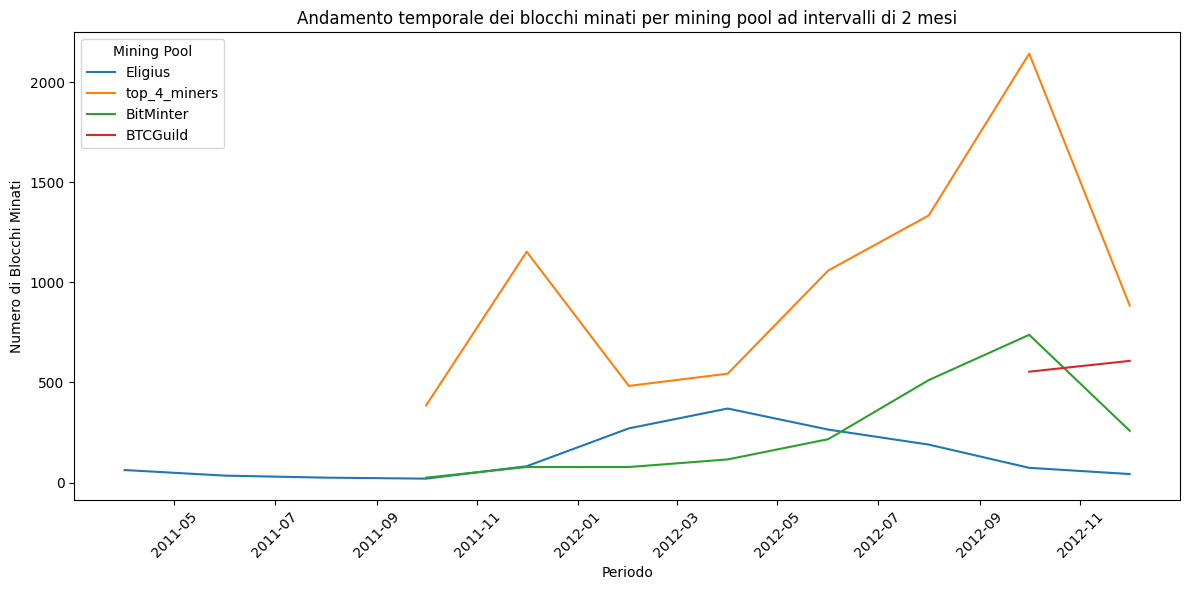

In [16]:
#NUMERO BLOCCHI MINATI PER INTERVALLI TEMPORALI DI DUE MESI

#import matplotlib.pyplot as plt
#import pandas as pd

df_blocks = df_da_deanomizzare.merge(df_Transactions[["txId","timestamp"]], on="txId")
df_blocks = df_blocks[ df_blocks["name_entity"] != "Others" ]

#creo una nuova colonna che converte il timestamp in un periodo mensile
df_blocks['year_month'] = df_blocks['timestamp'].dt.to_period('M')

#riconverto in timestamp
#attraverso .apply e una lambda function ottengo l'inizio mese di ogni intervallo di 2 mesi.
#lambda x: x - pd.DateOffset(months=x.month % 2) sottrae 0 mesi se il mese è dispari gennaio, merzo etc.. , 1 mese se è pari
#il metodo DateOffset di pandas permette di spostare le date di una certa "quantità" in modo flessibile.
df_blocks['two_months_interval'] = df_blocks['year_month'].dt.to_timestamp().apply(lambda x: x - pd.DateOffset(months=x.month % 2))

#raggruppo il dataframe per nome entità e intervallo di due mesi.
#.size: calcola il numero di righe (blocchi) in ciascun gruppo.
#creo un nuovo dataFrame con il conteggio dei blocchi per ogni intervallo di due mesi e ogni entità.
block_time_series = df_blocks.groupby(['name_entity', 'two_months_interval']).size().reset_index(name='block_count')

print(f"DataFrame preparato per il grafico:\n{block_time_series}\n")
print(f"Controllo eventuali valori nulli:\n{block_time_series.isna().sum()}\n") 

block_time_series = block_time_series.sort_values('two_months_interval')

plt.figure(figsize=(12, 6))

entities = block_time_series['name_entity'].unique()
#per ogni entità (mining pools e altri) traccio un plot
for entity in entities:
    entity_data = block_time_series[block_time_series['name_entity'] == entity]
    plt.plot(entity_data['two_months_interval'], entity_data['block_count'], label=entity)

plt.title('Andamento temporale dei blocchi minati per mining pool ad intervalli di 2 mesi')
plt.xlabel('Periodo')
plt.ylabel('Numero di Blocchi Minati')
plt.xticks(rotation=45)
plt.legend(title='Mining Pool')
plt.tight_layout()
plt.show()


In [17]:
#ANALISI punto 2) 

#PREPARAZIONE DATI 

#ho usato un workaround per ottenere la somma delle fees per i blocchi minati dalle entità deanomizzate:

#RIGHT join per ottenere le fee di TUTTE le transazioni dal dataframe_transactions (quindi anche quelle senza entità associata)
df_temp = df_blocks[["name_entity", "txId"]].merge(df_Transactions[["txId", "blockId","fee"]], on="txId", how="right")

#raggruppo per blockid e faccio la somma di tutte le fee associati al blocco. 
df_fees = df_temp.groupby(['blockId'])['fee'].sum().reset_index(name='tot_fees')

#LEFT join su un dataframe di appoggio, per avere le entità dei blocchi del df_blocks con le transazioni coinbase.
#ogni blocco può contenere più transazioni, ma a me interessa solo una riga per blocco
#voglio la coinbase perché mi servirà dopo per il calcolo della reward
df_temp = df_blocks[["name_entity", "txId"]].merge(df_Coinbase[["txId", "blockId","fee","timestamp"]], on="txId", how="left")

#LEFT join per unire i risultati delle fee precedentemente calcolate con le entità coinvolte nelle transazioni.
df_fees = df_temp[["name_entity","blockId","txId","timestamp"]].merge(df_fees, on="blockId", how="left")

#print(f"DATAFRAME DELLE ENTITà CON I BLOCCHI CHE HANNO MINATO E IL TOTALE DELLE FEES ASSOCIATI AL BLOCCO:\n{df_fees}")

#LEFT join per prendere gli outputs associati alla 
df_temp = df_fees.merge(df_Outputs[["txId","amount"]], on="txId", how="left")
df_temp['year_month'] = df_temp['timestamp'].dt.to_period('M')
df_temp['two_months_interval'] = df_temp['year_month'].dt.to_timestamp().apply(lambda x: x - pd.DateOffset(months=x.month % 2))
df_rewards = df_temp.groupby("name_entity")["amount"].sum().reset_index(name='coinbase_reward')

df_temp_fees = df_temp.groupby(["name_entity","two_months_interval"])["tot_fees"].sum().reset_index(name='tot_fees')
df_temp_coinbase_reward = df_temp.groupby(["name_entity","two_months_interval"])["amount"].sum().reset_index(name='coinbase_reward')
df_PREPARATO = df_temp_fees.merge(df_temp_coinbase_reward,on=["name_entity","two_months_interval"])
df_PREPARATO["tot_reward"]=df_PREPARATO["tot_fees"] + df_PREPARATO["coinbase_reward"]


print(f"DATAFRAME DELLE ENTITà CON I BLOCCHI MINATI E LE RICOMPENSE ASSOCIATE\n{df_PREPARATO}\n")

#print(df_PREPARATO.groupby("name_entity")["tot_reward"].sum().reset_index(name='coinbase_reward'))

df_rew_fees = df_fees.groupby("name_entity")["tot_fees"].sum().reset_index(name="tot_fees")
#print(df_rew_fees)

df_tot = df_rewards.merge(df_rew_fees, on="name_entity")
df_tot["tot_reward"] = df_tot["coinbase_reward"] + df_tot["tot_fees"]

#funzione per convertire le righe del df_tot da satoshi a bitcoin
def convert_to_btc(row):
    row["coinbase_reward"] = row["coinbase_reward"] / 10**8
    row["tot_fees"] = row["tot_fees"] / 10**8
    row["tot_reward"] = row["tot_reward"] / 10**8
    return row

df_tot = df_tot.apply(convert_to_btc, axis=1)
df_tot

DATAFRAME DELLE ENTITà CON I BLOCCHI MINATI E LE RICOMPENSE ASSOCIATE
     name_entity two_months_interval      tot_fees  coinbase_reward  \
0       BTCGuild          2012-10-01   10747392466    2668247392466   
1       BTCGuild          2012-12-01   15401753333    1535401753333   
2      BitMinter          2011-10-01       5429767     125005429767   
3      BitMinter          2011-12-01      77074332     390057796043   
4      BitMinter          2012-02-01      99337911     390099337911   
5      BitMinter          2012-04-01     452523274     580452523274   
6      BitMinter          2012-06-01    2262549183    1087262549183   
7      BitMinter          2012-08-01    4700839891    2564700839891   
8      BitMinter          2012-10-01    7428118632    3617428118632   
9      BitMinter          2012-12-01    5772168493     653272168493   
10       Eligius          2011-04-01    5926823642     315217038855   
11       Eligius          2011-06-01   79055139546     175380256449   
12     

,name_entity,coinbase_reward,tot_fees,tot_reward
0,BTCGuild,42036.491458,261.491458,42297.982916
1,BitMinter,94082.787632,207.980415,94290.768047
2,Eligius,70869.327266,94.452801,70963.780066
3,top_4_miners,375999.474742,1399.632349,377399.107091


Text(0, 0.5, 'Rewards')

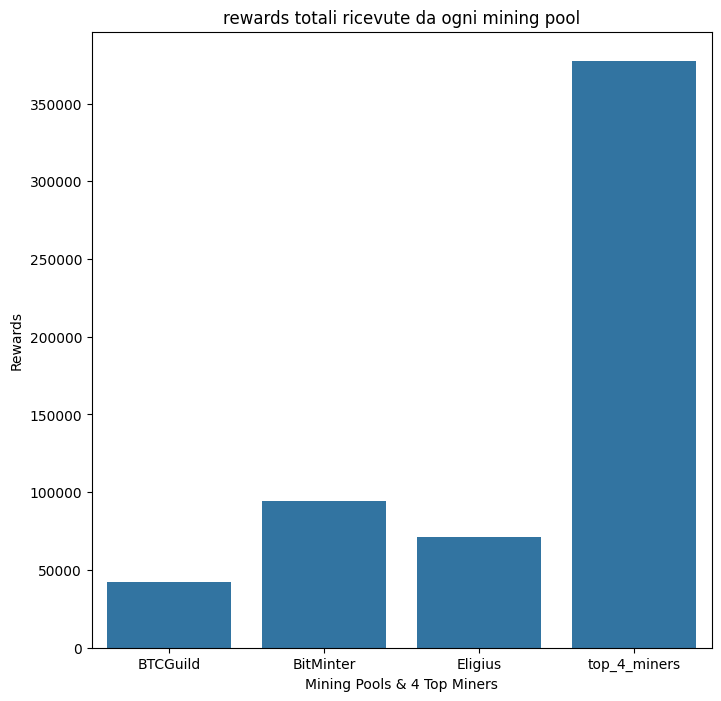

In [18]:
#Rewards totali ricevute da ogni mining pool

plt.figure(figsize=(8, 8))
sb.barplot(df_tot, x="name_entity",y="tot_reward")

plt.title('rewards totali ricevute da ogni mining pool')
plt.xlabel('Mining Pools & 4 Top Miners')
plt.ylabel('Rewards')

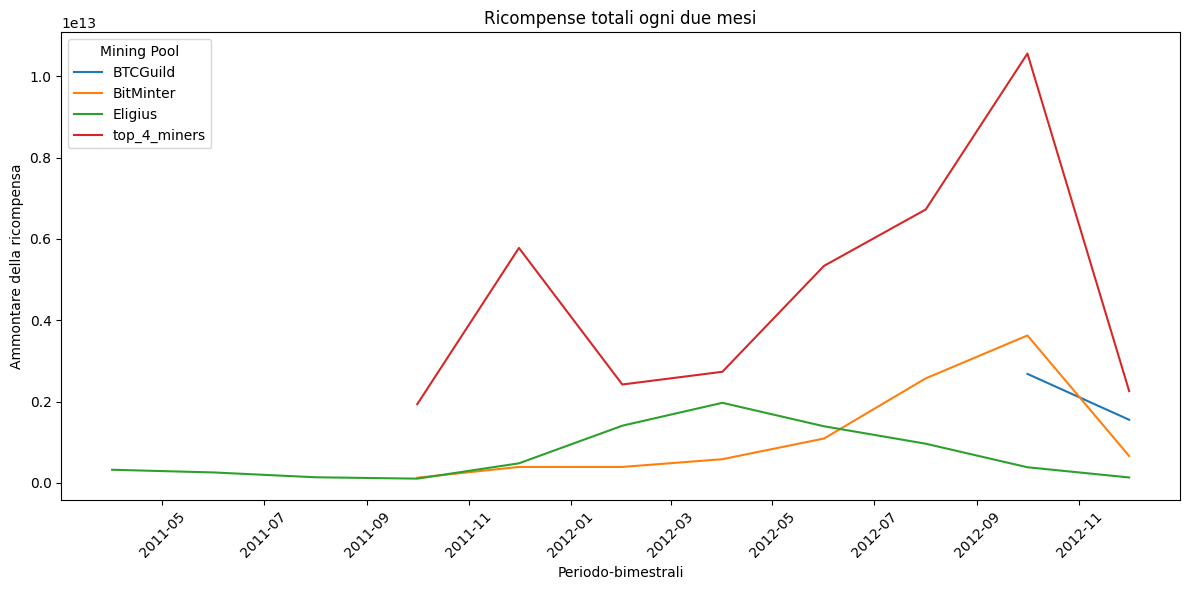

In [19]:
#2 - distribuzione delle reward totali ricevute da ogni mining pool mostrando l'andamento temporale, sempre per intervalli di due mesi;

plt.figure(figsize=(12, 6))

entities = df_PREPARATO['name_entity'].unique()

for entity in entities:
    entity_data = df_PREPARATO[df_PREPARATO['name_entity'] == entity]
    plt.plot(entity_data['two_months_interval'], entity_data['tot_reward'], label=entity)

plt.title('Ricompense totali ogni due mesi')
plt.xlabel('Periodo-bimestrali')
plt.ylabel('Ammontare della ricompensa')
plt.xticks(rotation=45)
plt.legend(title='Mining Pool')
plt.tight_layout()
plt.show()

L'analisi dei grafici relativi al numero di blocchi minati e alle ricompense per ciascuna delle mining pool (entrambi nel caso temporale), evidenzia una relazione stretta tra i due parametri, con una correlazione diretta: più blocchi una pool mina, maggiori sono le ricompense ottenute. 

Tuttavia, durante gli eventi di halving, in particolare nel 2012, si osserva una differenza tra le due curve di BTCGuild. Nonostante il numero di blocchi minati è in crescita, la curva delle ricompense diminuisce e questo è causato dall'evento dell'halving.

l'halving del 2012 ha comportato la riduzione delle ricompense dei Bitcoin distribuite per blocco da 50 BTC a 25 BTC (è un parametro fisso definito dal protocollo di Bitcoin).

--------------------------------------------------

ULTIMO PUNTO:
● considerare infine la Coinbase di Eligius mostrata in Fig.4. Questa transazione può essere 
reperita semplicemente digitando il suo hash nell’explorer. Come si può vedere in figura è 
possibile individuare la transazione successiva che spende i bitcoin di questa Coinbase 
seguendo la freccia in basso a destra in figura. Ripetendo il procedimento ricorsivamente più 
volte è possibile “seguire il flusso” dei bitcoin (una tecnica utilizzata in una tecnica di analisi 
chiamata taint analysis). Si chiede di tracciare il percorso dei bitcoin creati e di creare, 
mediante NetworkX, un grafo che descriva tale percorso. Si considerino al massimo k passi di 
tale percorso. 

Numero di nodi nel grafo: 16
Numero di archi nel grafo: 27


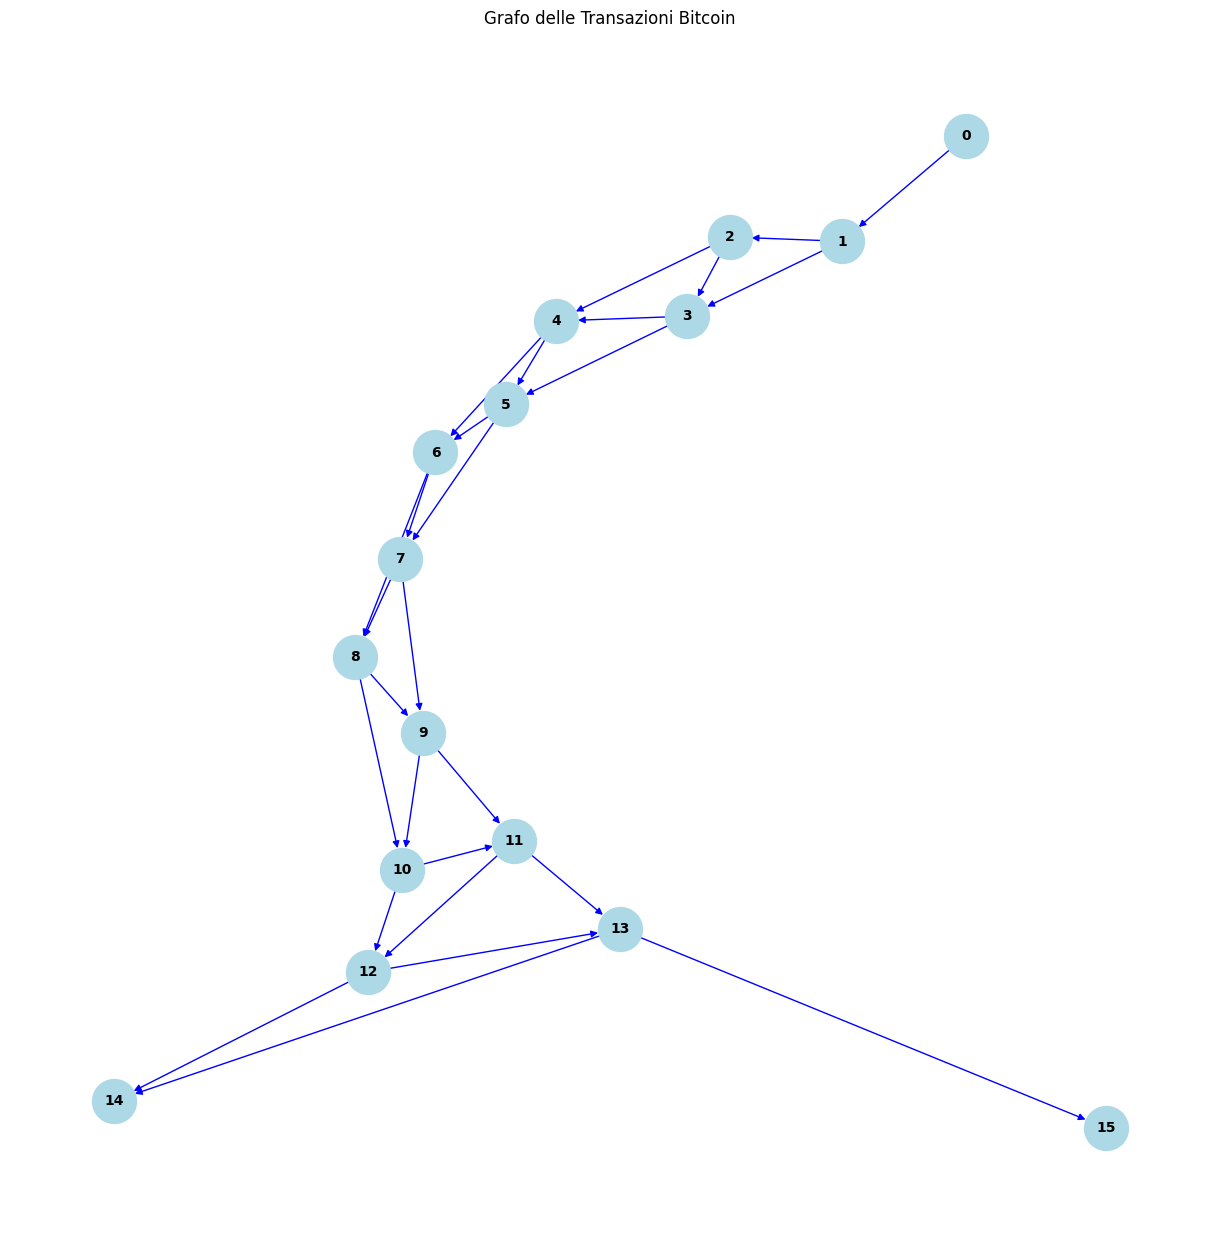

In [1]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import argparse
import random
import time
import os
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

url = "https://www.walletexplorer.com/"
target_address="c82c10925cc3890f1299"

K = 9 #numero k passi percorso dei bitcoin

options = webdriver.ChromeOptions()

prefs = {
        "profile.default_content_setting_values.cookies": 1,
        "profile.managed_default_content_settings.cookies": 2
    }

options.add_experimental_option("prefs", prefs)

service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=options)

driver.get(url)

WebDriverWait(driver, 10).until(
            lambda driver: driver.execute_script("return document.readyState") == "complete"
    )

text_field = WebDriverWait(driver, 10).until(
    EC.visibility_of_element_located((By.XPATH, "/html/body/div[2]/form/p/label/input"))
)

text_field.clear()
text_field.send_keys(target_address)

driver.find_element(By.XPATH, "/html/body/div[2]/form/p/input").click()

WebDriverWait(driver, 10).until(
            lambda driver: driver.execute_script("return document.readyState") == "complete"
    )

#restituisce l'indirizzo dell'attuale transazione, il nostro nodo attuale, dal DOM
def get_address():
    return driver.find_element(By.XPATH, "//table[@class='info']//tr[th[text()='Txid']]/td").text

#restituisce la lista degli indirizzi associati agli outputs, prendendoli dal dom
def get_outputs():
    tab = driver.find_element(By.XPATH, "/html/body/div[2]/table[2]/tbody/tr[2]/td[2]/table")
    rows = tab.find_elements(By.TAG_NAME, "tr")
    if len(rows) == 0 : 
        return []
    l = []
    for row in rows:
        try:
            link = row.find_element(By.CLASS_NAME, "small").find_element(By.TAG_NAME,"a")
            l.append(link.get_attribute("href"))
        except:
            # If no link is found in this row, skip it
            continue
    return l

#funzione ricorsiva per esplorare i path delle transazioni dalla transazione target (concetto del taint analisys)
#actual_node_url:url della transazione target
#k: numero dei passi
#g: il grafo da costruire
#i: un intero "count" che aumenta di 1 progressivamente, usato per assegnare al nodo un intero univoco.
def f_rec(actual_node_url,k,g,i):
    if k <= 0:
        return -1
    driver.get(actual_node_url)
    WebDriverWait(driver, 5).until(
            lambda driver: driver.execute_script("return document.readyState") == "complete"
    )
    actual_node_address = get_address()
    g.add_node(i, address=actual_node_address, url=actual_node_url)
    j=i
    for url in get_outputs():
        i=i+1
        time.sleep(random.uniform(2, 5))
        next_node_address = f_rec(url,k-1,g,i)
        if next_node_address != -1:
            g.add_edge(j, i)
    return actual_node_address
    
g = nx.DiGraph()

f_rec(driver.current_url,K,g,0)

time.sleep(5)
driver.quit()

print(f"Numero di nodi nel grafo: {g.number_of_nodes()}")
print(f"Numero di archi nel grafo: {g.number_of_edges()}")

plt.figure(figsize=(12, 12))
nx.draw(g, with_labels=True, font_weight='bold', node_size=1000, font_size=10, edge_color='blue', node_color='lightblue')
plt.title("Grafo delle Transazioni Bitcoin")
plt.show()

In [3]:
clustering_coeff = nx.average_clustering(g)
print(f"Coefficiente di clustering medio: {clustering_coeff}")
if nx.is_strongly_connected(g):
    avg_length = nx.average_shortest_path_length(g)
    print(f"Lunghezza cammino medio: {avg_length}")
else:
    print("Il grafo non è fortemente connesso, quindi non posso calcolare la lunghezza del cammino medio.")
degree_dict = dict(g.degree())
print("Grado dei nodi:", degree_dict)

Coefficiente di clustering medio: 0.22916666666666666
Il grafo non è fortemente connesso, quindi non posso calcolare la lunghezza del cammino medio.
Grado dei nodi: {0: 1, 1: 3, 2: 3, 3: 4, 4: 4, 5: 4, 6: 4, 7: 4, 8: 4, 9: 4, 10: 4, 11: 4, 12: 4, 13: 4, 14: 2, 15: 1}


--------------------------------------
Considerazioni:

Il coefficiente di clustering medio del grafo è risultato pari a 0.2291 (circa il 23%). Questo valore indica una bassa densità di connessioni locali tra i nodi vicini. Dal grafo si vede che i triangoli ci sono, ma sono piccoli e i nodi tendono ad essere poco interconnessi tra loro. Questo potrebbe essere tipico di reti come quella delle transazioni Bitcoin, dove gli indirizzi non sono fortemente collegati tra di loro, ma piuttosto si collegano in modo lineare o con poche connessioni dirette.

Il grado dei nodi è distribuito in modo uniforme (tra 1 e 4), il che implica che non esistano nodi particolarmente centrali nel grafo (hub dominanti). La centralità dei nodi, che misura l'importanza di un nodo in relazione agli altri, sembra essere distribuita uniformemente.

La rete sembra essere resiliente: non ci sono hub dominanti che tagliandoli fuori dalla rete potrebbero comportare gravi danni alla rete.

